In [2]:
import json
import urllib.request
import pandas as pd

# 1. Fetch game data from the official Liiga API
url = "https://liiga.fi/api/v2/games?season=2025"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

with urllib.request.urlopen(req) as response:
    data = json.loads(response.read().decode())

# 2. Flatten nested JSON structure into a tabular DataFrame
games_df = pd.json_normalize(data)

# 3. Print all flattened column names to verify exact names
print("Available columns in the dataset:")
print(games_df.columns.tolist())

Available columns in the dataset:
['id', 'season', 'start', 'periods', 'finishedType', 'started', 'ended', 'gameTime', 'spectators', 'currentPeriod', 'stale', 'serie', 'gameWeek', 'homeTeam.teamId', 'homeTeam.teamPlaceholder', 'homeTeam.teamName', 'homeTeam.goals', 'homeTeam.timeOut', 'homeTeam.goalEvents', 'homeTeam.powerplayInstances', 'homeTeam.powerplayGoals', 'homeTeam.shortHandedInstances', 'homeTeam.shortHandedGoals', 'homeTeam.ranking', 'homeTeam.gameStartDateTime', 'homeTeam.logos.darkBg', 'homeTeam.logos.lightBg', 'homeTeam.logos.darkBgOriginal', 'homeTeam.logos.lightBgOriginal', 'awayTeam.teamId', 'awayTeam.teamPlaceholder', 'awayTeam.teamName', 'awayTeam.goals', 'awayTeam.timeOut', 'awayTeam.goalEvents', 'awayTeam.powerplayInstances', 'awayTeam.powerplayGoals', 'awayTeam.shortHandedInstances', 'awayTeam.shortHandedGoals', 'awayTeam.ranking', 'awayTeam.gameStartDateTime', 'awayTeam.logos.darkBg', 'awayTeam.logos.lightBg', 'awayTeam.logos.darkBgOriginal', 'awayTeam.logos.ligh

In [3]:
# 1. Select key columns using exact names from normalized JSON
selected_cols = [
    "id",
    "homeTeam.teamName",
    "awayTeam.teamName",
    "homeTeam.goals",
    "awayTeam.goals",
    "spectators",
    "homeTeam.expectedGoals",
    "awayTeam.expectedGoals",
]

df_liiga = games_df[selected_cols].copy()

# 2. Rename columns for clean and readable code
df_liiga = df_liiga.rename(
    columns={
        "homeTeam.teamName": "home_team",
        "awayTeam.teamName": "away_team",
        "homeTeam.goals": "home_goals",
        "awayTeam.goals": "away_goals",
        "homeTeam.expectedGoals": "home_xg",
        "awayTeam.expectedGoals": "away_xg",
    }
)

# 3. Create target binary variable for ML classification: 1 if Home Team wins, 0 if Away Team wins
df_liiga["home_win"] = (df_liiga["home_goals"] > df_liiga["away_goals"]).astype(
    int
)

# 4. Display the first 5 rows
df_liiga.head()

,id,home_team,away_team,home_goals,away_goals,spectators,home_xg,away_xg,home_win
0,1006,Sport,JYP,3,3,4500,NaN,NaN,0
1,1007,Lukko,Ässät,2,0,4500,1.80,0.77,1
2,1008,JYP,TPS,1,3,4500,NaN,NaN,0
3,1009,Ässät,SaiPa,0,2,4500,1.23,0.83,0
4,1010,TPS,Sport,0,0,4500,0.53,0.72,0


In [4]:
# 1. Inspect data types and non-null counts
print("=== DATASET INFO ===")
df_liiga.info()

# 2. Check missing values (NaN) per column
print("\n=== MISSING VALUES ===")
print(df_liiga.isnull().sum())

# 3. Descriptive statistics for numerical variables
print("\n=== DESCRIPTIVE STATISTICS ===")
display(df_liiga.describe())

# 4. Check class balance for target variable (Home Wins vs Away Wins)
print("\n=== TARGET VARIABLE DISTRIBUTION ===")
print(df_liiga["home_win"].value_counts(normalize=True))

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          614 non-null    int64  
 1   home_team   614 non-null    object 
 2   away_team   614 non-null    object 
 3   home_goals  614 non-null    int64  
 4   away_goals  614 non-null    int64  
 5   spectators  614 non-null    int64  
 6   home_xg     582 non-null    float64
 7   away_xg     582 non-null    float64
 8   home_win    614 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 43.3+ KB

=== MISSING VALUES ===
id             0
home_team      0
away_team      0
home_goals     0
away_goals     0
spectators     0
home_xg       32
away_xg       32
home_win       0
dtype: int64

=== DESCRIPTIVE STATISTICS ===


,id,home_goals,away_goals,spectators,home_xg,away_xg,home_win
count,614.000000,614.000000,614.000000,614.000000,582.000000,582.000000,614.000000
mean,5817.799674,2.952769,2.710098,4385.628664,2.770155,2.522027,0.532573
std,15878.503914,1.718164,1.659614,2270.005240,0.874530,0.850825,0.499345
min,1.000000,0.000000,0.000000,0.000000,0.530000,0.340000,0.000000
25%,154.250000,2.000000,2.000000,3015.500000,2.130000,1.940000,0.000000
50%,307.500000,3.000000,3.000000,4013.500000,2.770000,2.440000,1.000000
75%,460.750000,4.000000,4.000000,5147.500000,3.367500,3.060000,1.000000
max,52454.000000,9.000000,9.000000,12700.000000,5.840000,6.320000,1.000000



=== TARGET VARIABLE DISTRIBUTION ===
home_win
1    0.532573
0    0.467427
Name: proportion, dtype: float64


In [5]:
# Grouping data by match outcome (home_win) to calculate mean and median goals
df_liiga.groupby("home_win")["home_goals"].agg(["mean", "median"])

,mean,median
home_win,,
0,1.808362,2.0
1,3.957187,4.0


In [6]:
 
df_liiga["home_win"].value_counts()

home_win
1    327
0    287
Name: count, dtype: int64

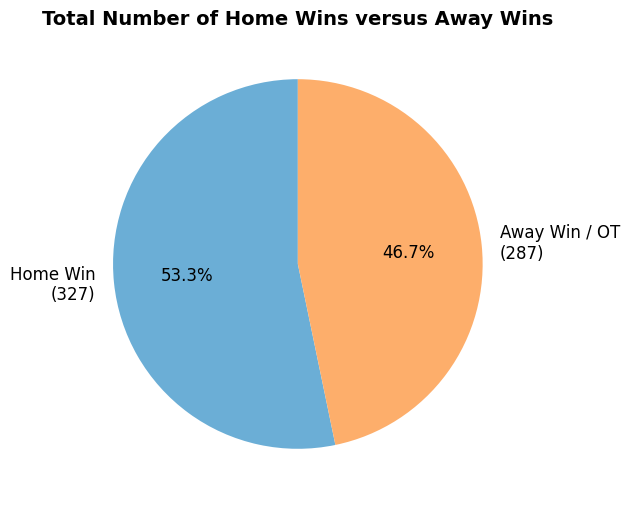

In [7]:
import matplotlib.pyplot as plt

# Data for pie chart
outcome_counts = df_liiga["home_win"].value_counts()
labels = [f"Home Win\n({outcome_counts[1]})", f"Away Win / OT\n({outcome_counts[0]})"]
colors = ["#6baed6", "#fdae6b"]  # Light blue and orange (matching Google style)

# Plotting
plt.figure(figsize=(6, 6))
plt.pie(
    outcome_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 12},
)
plt.title(
    "Total Number of Home Wins versus Away Wins", fontsize=14, fontweight="bold"
)

# Save figure for presentation/report
plt.savefig("liiga_outcomes_pie_chart.png", dpi=300, bbox_inches="tight")
plt.show()